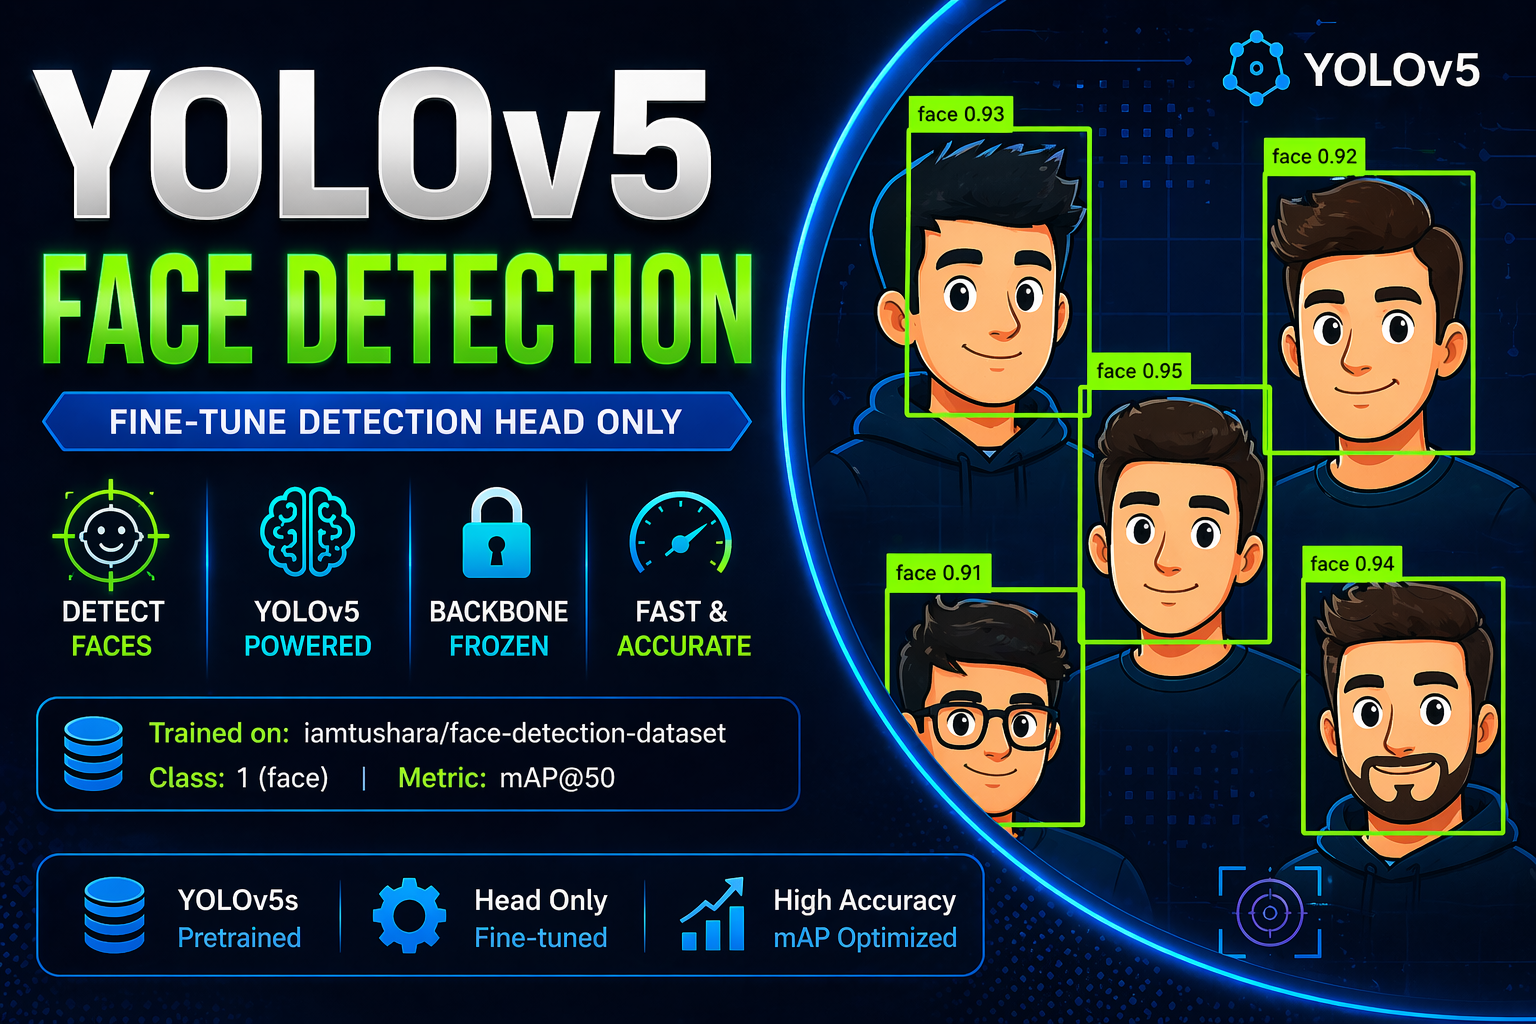

In [1]:
from IPython.display import Image, display
display(Image(filename='/kaggle/input/datasets/mhassansaboor/yolov5-thumbnail/yolov5_thumbnail.png'))

# 🚀 **Face Detection with YOLOv5 (Head Fine-Tuning Only)**

This project focuses on training a **face detection model** using YOLOv5 by:

✨ Using a pretrained model  
✨ Freezing backbone + neck layers  
✨ Training **ONLY the detection head**  
✨ Evaluating performance using mAP, precision, recall  

📂 **Dataset:** Face Detection Dataset  
🧠 **Approach:** Transfer Learning (Head Fine-Tuning)

---

⚡ **Goal:**  
Efficiently adapt a pretrained YOLO model for **face-only detection** with minimal training cost.

# 📦 **Installing Dependencies**

We install the **Ultralytics YOLO package**, which provides:

✅ Easy API for training and inference  
✅ Built-in support for YOLOv5 models  
✅ Efficient training pipeline  

📌 Version is pinned to avoid compatibility issues.

In [2]:
!pip install ultralytics==8.2.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.8/750.8 kB 15.5 MB/s eta 0:00:0000:01


# ⚙️ **Environment Setup & Imports**

In this step, we:

🔹 Import required libraries (PyTorch, NumPy, Matplotlib, etc.)  
🔹 Load YOLO API  
🔹 Check system configuration  

💡 We also verify:
- Python version 🐍  
- PyTorch version 🔥  
- GPU availability ⚡  
- VRAM capacity 💾  

This ensures the environment is ready for training.

In [32]:
import os
import sys
import ray
import shutil
import torch
import torch.serialization
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
import importlib
import random

# Ultralytics YOLO API
from ultralytics import YOLO

# Torch utilities
from torch import nn

print("=" * 60)
print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("=" * 60)

Python      : 3.12.12
PyTorch     : 2.10.0+cu128
CUDA available : True
GPU         : Tesla T4
VRAM        : 15.6 GB


# 📂 **Dataset & Model Path Verification**

We define and verify:

📁 Training images  
📁 Validation images  
📁 Labels (train + validation)  
📦 Pretrained YOLO model  

---

✅ This step ensures:
- All paths exist  
- Dataset is correctly loaded  
- Training won't fail due to missing files  

📊 We also count total training & validation samples.

In [4]:
# ---- Dataset paths ----------------------------------------
TRAIN_IMAGES = "/kaggle/input/datasets/iamtushara/face-detection-dataset/merged/images/train"
VAL_IMAGES   = "/kaggle/input/datasets/iamtushara/face-detection-dataset/merged/images/validation"
TRAIN_LABELS = "/kaggle/input/datasets/iamtushara/face-detection-dataset/merged/labels/train"
VAL_LABELS   = "/kaggle/input/datasets/iamtushara/face-detection-dataset/merged/labels/validation"

# ---- Pretrained model path --------------------------------
# Using yolov5su (small-ultralytics) — good balance of speed and accuracy
# You may also try yolov5mu (medium) for better accuracy at cost of time
MODEL_PATH = "/kaggle/input/models/ultralytics/yolov5/pytorch/default/1/yolov5su.pt"

# ---- YAML config path  ----
YAML_PATH  = "/kaggle/input/datasets/mhassansaboor/face-detection/face_detection.yaml"

# Verify paths exist
paths_to_check = {
    "Train images" : TRAIN_IMAGES,
    "Val images"   : VAL_IMAGES,
    "Train labels" : TRAIN_LABELS,
    "Val labels"   : VAL_LABELS,
    "Model (.pt)"  : MODEL_PATH,
}

print("Checking required paths...")
all_ok = True
for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {name}: {path}")
    if not exists:
        all_ok = False

# Count training samples
try:
    n_train = len(list(Path(TRAIN_IMAGES).glob("*")))
    n_val   = len(list(Path(VAL_IMAGES).glob("*")))
    print(f"\n  Training images   : {n_train}")
    print(f"  Validation images : {n_val}")
except Exception as e:
    print(f"  Could not count images: {e}")

if all_ok:
    print("\nAll paths verified ✓")
else:
    print("\nWarning: some paths are missing — check your dataset imports.")

Checking required paths...
  ✓  Train images: /kaggle/input/datasets/iamtushara/face-detection-dataset/merged/images/train
  ✓  Val images: /kaggle/input/datasets/iamtushara/face-detection-dataset/merged/images/validation
  ✓  Train labels: /kaggle/input/datasets/iamtushara/face-detection-dataset/merged/labels/train
  ✓  Val labels: /kaggle/input/datasets/iamtushara/face-detection-dataset/merged/labels/validation
  ✓  Model (.pt): /kaggle/input/models/ultralytics/yolov5/pytorch/default/1/yolov5su.pt

  Training images   : 26266
  Validation images : 6573

All paths verified ✓


# 📝 **Dataset Configuration (YAML File)**

YOLO requires a YAML config file specifying:

📂 Training path  
📂 Validation path  
🔢 Number of classes (nc = 1)  
🏷️ Class names → ['face']  

---

⚡ If YAML is not uploaded, we automatically create it.

💡 Since this is a **face-only model**, we use:
👉 `nc = 1`

In [5]:
# We write the YAML directly if it wasn't uploaded
YAML_CONTENT = f"""# Face Detection Dataset Config
# nc=1 because we ONLY detect faces — no other classes
train: {TRAIN_IMAGES}
val:   {VAL_IMAGES}
nc: 1
names:
  - face
"""

# Write to a writable location in the working directory
YAML_LOCAL = "/kaggle/working/face_detection.yaml"
with open(YAML_LOCAL, "w") as f:
    f.write(YAML_CONTENT)

# Use the uploaded YAML if it exists, otherwise use the one we just wrote
if os.path.exists(YAML_PATH):
    YAML_TO_USE = YAML_PATH
    print(f"Using uploaded YAML: {YAML_PATH}")
else:
    YAML_TO_USE = YAML_LOCAL
    print(f"YAML not found at {YAML_PATH}, using locally created: {YAML_LOCAL}")

print("\nYAML contents:")
print("-" * 40)
with open(YAML_TO_USE) as f:
    print(f.read())

Using uploaded YAML: /kaggle/input/datasets/mhassansaboor/face-detection/face_detection.yaml

YAML contents:
----------------------------------------
# ============================================================
# face_detection.yaml
# Dataset configuration for YOLOv5 face detection fine-tuning
# Upload this file separately to your Kaggle notebook
# ============================================================

# Paths to train/val image directories
train: /kaggle/input/datasets/iamtushara/face-detection-dataset/merged/images/train
val:   /kaggle/input/datasets/iamtushara/face-detection-dataset/merged/images/validation

# Number of classes
# IMPORTANT: Only 1 class — 'face'. No other class is used.
nc: 1

# Class names list (must match label index 0 in annotation files)
names:
  - face



# 🔍 **Label Validation (Sanity Check)**

We verify annotation correctness:

📌 YOLO label format:
`class_id cx cy width height` (normalized)

---

✅ Checks performed:
- All labels belong to class **0 (face)**  
- No unexpected class IDs  
- Count total bounding boxes  

---

⚠️ If invalid labels exist, they are reported.

In [6]:
print("Validating label files for class consistency...")

label_files = list(Path(TRAIN_LABELS).glob("*.txt"))
unexpected_classes = set()
total_boxes = 0
face_boxes  = 0

# Sample up to 500 label files to keep this fast
sample_files = label_files[:500]

for lf in sample_files:
    with open(lf, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                total_boxes += 1
                if cls_id == 0:
                    face_boxes += 1
                else:
                    unexpected_classes.add(cls_id)

print(f"  Sampled {len(sample_files)} label files")
print(f"  Total bounding boxes : {total_boxes}")
print(f"  Face boxes (class 0) : {face_boxes}")
if unexpected_classes:
    print(f"  WARNING — unexpected class IDs found: {unexpected_classes}")
    print("  These will be ignored because YAML only defines class 0 = face")
else:
    print("  All boxes are class 0 (face) ✓")

Validating label files for class consistency...
  Sampled 500 label files
  Total bounding boxes : 3600
  Face boxes (class 0) : 3600
  All boxes are class 0 (face) ✓


# 🧠 **Model Loading & Freezing Strategy**

We load a pretrained YOLOv5 model and apply:

❄️ **Layer Freezing Strategy:**
- Freeze Backbone (feature extraction)
- Freeze Neck (feature fusion)
- Train ONLY Detection Head 🎯  

---

📊 Why?

✅ Faster training  
✅ Prevent overfitting  
✅ Retain learned features  

---

📌 Only the **Detect() layer** is trainable.

In [7]:
# Fix for PyTorch 2.6+ — torch.load now defaults to weights_only=True
# which blocks loading YOLOv5 checkpoints that contain custom classes.
# We allowlist the required ultralytics globals before loading.

# ---- Patch: allowlist ultralytics globals for safe loading ----
# These are the classes PyTorch encounters inside the .pt checkpoint.
# We trust them because they come from the official Kaggle ultralytics model.
try:
    from ultralytics.nn.tasks import DetectionModel
    from ultralytics.nn.modules import (
        Conv, C2f, SPPF, Detect, DFL,
        Bottleneck, C3, SPP, Focus, BottleneckCSP
    )
    import ultralytics.nn.modules as ult_modules
    import ultralytics.nn.tasks as ult_tasks

    # Add all ultralytics classes as safe globals
    torch.serialization.add_safe_globals([
        DetectionModel,
        ult_tasks.DetectionModel,
    ])

    # Broader allowlist — covers all submodules Ultralytics embeds in checkpoints
    for attr_name in dir(ult_modules):
        obj = getattr(ult_modules, attr_name)
        try:
            if isinstance(obj, type):
                torch.serialization.add_safe_globals([obj])
        except Exception:
            pass

    print("Ultralytics globals allowlisted for torch.load ✓")

except Exception as e:
    print(f"Note: Could not pre-allowlist all globals ({e})")
    print("Falling back to weights_only=False patch...")

# ---- Nuclear fallback: monkey-patch torch.load to use weights_only=False ----
# This is safe here because the model comes from Kaggle's official ultralytics hub.
_original_torch_load = torch.load

def _patched_torch_load(f, map_location=None, pickle_module=None,
                         weights_only=None, mmap=None, **kwargs):
    """
    Wrapper around torch.load that forces weights_only=False for .pt files
    containing ultralytics DetectionModel objects. Safe for trusted checkpoints.
    """
    return _original_torch_load(
        f,
        map_location=map_location,
        weights_only=False,   # Required for ultralytics YOLOv5 checkpoints
        **{k: v for k, v in kwargs.items()
           if k not in ("pickle_module", "mmap")}
    )

torch.load = _patched_torch_load
print("torch.load patched to use weights_only=False ✓")

# ---- Now load the model safely ----------------------------
print("\nLoading pretrained YOLOv5s model...")
from ultralytics import YOLO

model = YOLO(MODEL_PATH)

# Restore original torch.load after model is loaded
torch.load = _original_torch_load
print("torch.load restored to original ✓")

# ---- Access the underlying PyTorch nn.Module --------------
pt_model = model.model   # The actual nn.Module

# ---- Step 1: Freeze ALL parameters -----------------------
for param in pt_model.parameters():
    param.requires_grad = False
print("\nAll parameters frozen.")

# ---- Step 2: Identify the detection head -----------------
# In YOLOv5 the Detect() head is always the last sequential child
detection_head = pt_model.model[-1]
print(f"Detection head type : {type(detection_head).__name__}")

# Safety check — make sure we actually found the Detect module
head_type_name = type(detection_head).__name__
if "Detect" not in head_type_name:
    # Walk children to find it
    for child in reversed(list(pt_model.model.children())):
        if "Detect" in type(child).__name__:
            detection_head = child
            print(f"  (Found Detect head by walking: {type(detection_head).__name__})")
            break

# ---- Step 3: Unfreeze ONLY the detection head ------------
for param in detection_head.parameters():
    param.requires_grad = True

# ---- Step 4: Verify -------------------------------------
total_params     = sum(p.numel() for p in pt_model.parameters())
frozen_params    = sum(p.numel() for p in pt_model.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)
head_params      = sum(p.numel() for p in detection_head.parameters())

print("\n" + "=" * 60)
print("Parameter summary:")
print(f"  Total parameters      : {total_params:,}")
print(f"  Frozen (backbone+neck): {frozen_params:,}")
print(f"  Trainable (head only) : {trainable_params:,}")
print(f"  Head parameters       : {head_params:,}")

# Soft assert with helpful message
if trainable_params != head_params:
    print(f"\n  WARNING: trainable={trainable_params:,} != head={head_params:,}")
    print("  This can happen if the Detect module shares params with neck layers.")
    print("  Check layer-by-layer status below.")
else:
    print("\n  ✓ Only the detection head will be updated during training")
print("=" * 60)

# ---- Layer-by-layer status (first 6 + head layers) ------
print("\nLayer-by-layer freeze status (sample):")
for i, (name, param) in enumerate(pt_model.named_parameters()):
    status = "TRAIN ✓" if param.requires_grad else "frozen  "
    # Print first 6 params and any head params
    if i < 6 or "model.24" in name or "model.25" in name or "model.23" in name:
        print(f"  [{status}]  {name:50s}  {param.numel():>8,} params")
print("  ... (all backbone and neck layers are frozen) ...")

Ultralytics globals allowlisted for torch.load ✓
torch.load patched to use weights_only=False ✓

Loading pretrained YOLOv5s model...
torch.load restored to original ✓

All parameters frozen.
Detection head type : Detect

Parameter summary:
  Total parameters      : 9,153,152
  Frozen (backbone+neck): 7,006,144
  Trainable (head only) : 2,147,008
  Head parameters       : 2,147,008

  ✓ Only the detection head will be updated during training

Layer-by-layer freeze status (sample):
  [frozen  ]  model.0.conv.weight                                    3,456 params
  [frozen  ]  model.0.bn.weight                                         32 params
  [frozen  ]  model.0.bn.bias                                           32 params
  [frozen  ]  model.1.conv.weight                                   18,432 params
  [frozen  ]  model.1.bn.weight                                         64 params
  [frozen  ]  model.1.bn.bias                                           64 params
  [frozen  ]  model.23.

# 🏋️ **Model Training (Head Only Fine-Tuning)**

We train the model with:

📅 Epochs: 30  
📏 Image Size: 640  
📦 Batch Size: 16  
📉 Learning Rate: 0.001  

---

🔥 Key Setting:
👉 `freeze = 24`

This ensures:
- Layers 0–23 ❄️ frozen  
- Layer 24 🎯 trainable (detection head)

---

📈 Trainer handles:
- Loss calculation  
- Augmentation  
- mAP evaluation  
- Early stopping  

In [9]:
# ---- PATCH 1: Fix ray missing attribute -------------------
import ray.train._internal.session as _ray_session
_ray_session._get_session = lambda: None
print("PATCH 1: ray._get_session fixed ✓")

# ---- PATCH 2: Fix torch.load weights_only=True -----------
_original_torch_load = torch.load

def _safe_torch_load(f, map_location=None, weights_only=None, **kwargs):
    return _original_torch_load(f, map_location=map_location, weights_only=False, **kwargs)

torch.load = _safe_torch_load
print("PATCH 2: torch.load weights_only fixed ✓")

# ---- PATCH 3: Disable WandB ------------------------------
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"]     = "disabled"
try:
    from ultralytics.utils import SETTINGS
    SETTINGS["wandb"] = False
except Exception:
    pass
print("PATCH 3: WandB disabled ✓")

print("\nAll patches applied. Starting training...\n")

# ---- Training --------------------------------------------
EPOCHS       = 30
IMG_SIZE     = 640
BATCH_SIZE   = 16
PROJECT_NAME = "face_detection"
RUN_NAME     = "face_head_only"

print(f"  Epochs     : {EPOCHS}")
print(f"  Image size : {IMG_SIZE}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Freeze     : layers 0-23 (backbone + neck)")
print(f"  Trainable  : layer 24 (detection head only)")
print(f"  Save dir   : /kaggle/working/{PROJECT_NAME}/{RUN_NAME}\n")

results = model.train(
    data         = YAML_TO_USE,
    epochs       = EPOCHS,
    imgsz        = IMG_SIZE,
    batch        = BATCH_SIZE,
    workers      = 2,
    freeze       = 24,
    project      = PROJECT_NAME,
    name         = RUN_NAME,
    exist_ok     = True,
    device       = 0,
    save         = True,
    plots        = True,
    patience     = 10,
    verbose      = True,
)

torch.load = _original_torch_load
print("torch.load restored ✓")

SAVE_DIR        = f"/kaggle/working/{PROJECT_NAME}/{RUN_NAME}"
BEST_MODEL_PATH = f"{SAVE_DIR}/weights/best.pt"

print("\nTraining complete! ✓")
print(f"Best model : {BEST_MODEL_PATH}")

PATCH 1: ray._get_session fixed ✓
PATCH 2: torch.load weights_only fixed ✓
PATCH 3: WandB disabled ✓

All patches applied. Starting training...

  Epochs     : 30
  Image size : 640
  Batch size : 16
  Freeze     : layers 0-23 (backbone + neck)
  Trainable  : layer 24 (detection head only)
  Save dir   : /kaggle/working/face_detection/face_head_only

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.0 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=/kaggle/input/models/ultralytics/yolov5/pytorch/default/1/yolov5su.pt, data=/kaggle/input/datasets/mhassansaboor/face-detection/face_detection.yaml, epochs=30, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=face_detection, name=face_head_only, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=

100%|██████████| 755k/755k [00:00<00:00, 19.4MB/s]
2026-04-22 05:46:06.124851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776836766.308752      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776836766.365905      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776836766.788388      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776836766.788439      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776836766.788442      5

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      3520  ultralytics.nn.modules.conv.Conv             [3, 32, 6, 2, 2]              
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     18816  ultralytics.nn.modules.block.C3              [64, 64, 1]                   
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    115712  ultralytics.nn.modules.block.C3              [128, 128, 2]                 
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  3    625152  ultralytics.nn.modules.block.C3              [256, 256, 3]                 
  7                  -1  1   1180672  ultralytics

100%|██████████| 6.23M/6.23M [00:00<00:00, 87.7MB/s]
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/checks.py:640: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(True):


AMP: checks passed ✅


...

                   all       6572      49974      0.765      0.499      0.565      0.288

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      30/30      8.87G      1.591      0.954      1.285         37        640: 100%|██████████| 1642/1642 [05:42<00:00,  4.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 206/206 [00:52<00:00,  3.91it/s]


                   all       6572      49974      0.766      0.499      0.565      0.288

30 epochs completed in 3.546 hours.
Optimizer stripped from face_detection/face_head_only/weights/last.pt, 18.5MB
Optimizer stripped from face_detection/face_head_only/weights/best.pt, 18.5MB

Validating face_detection/face_head_only/weights/best.pt...
Ultralytics YOLOv8.2.0 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 193 layers, 9111923 parameters, 0 gradients, 23.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 206/206 [00:52<00:00,  3.89it/s]


                   all       6572      49974      0.765      0.499      0.565      0.288
Speed: 0.1ms preprocess, 2.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to face_detection/face_head_only
torch.load restored ✓

Training complete! ✓
Best model : /kaggle/working/face_detection/face_head_only/weights/best.pt


# 📊 **Model Evaluation**

We evaluate the trained model using:

📌 Metrics:
- mAP@50 🎯  
- mAP@50-95 📉  
- Precision ✅  
- Recall 🔁  

---

💡 These metrics indicate:
- Detection accuracy  
- Localization quality  
- Model reliability  

---

🏆 Best model is automatically loaded for evaluation.

In [12]:
# BEST_MODEL_PATH = str(Path(results.save_dir) / "weights" / "best.pt")

# print(f"Loading best model from: {BEST_MODEL_PATH}")
# best_model = YOLO(BEST_MODEL_PATH)

# # Run validation
# val_results = best_model.val(
#     data   = YAML_TO_USE,
#     imgsz  = IMG_SIZE,
#     batch  = BATCH_SIZE,
#     device = 0,
#     verbose= True,
# )

# print("\n" + "=" * 60)
# print("Validation metrics:")
# print(f"  mAP@50        : {val_results.box.map50:.4f}")
# print(f"  mAP@50-95     : {val_results.box.map:.4f}")
# print(f"  Precision     : {val_results.box.mp:.4f}")
# print(f"  Recall        : {val_results.box.mr:.4f}")
# print("=" * 60)

# ===========================================================
# CELL 8: Load best model + quick validation summary
# ===========================================================

# import torch
# from pathlib import Path
# from ultralytics import YOLO

# Patch torch.load before loading the model
_orig_load  = torch.load
torch.load  = lambda f, *a, **kw: _orig_load(f, *a, **{**kw, "weights_only": False})

BEST_MODEL_PATH = "/kaggle/working/face_detection/face_head_only/weights/best.pt"
IMG_SIZE        = 640
BATCH_SIZE      = 16

print(f"Loading best model: {BEST_MODEL_PATH}")
best_model = YOLO(BEST_MODEL_PATH)

# Restore torch.load
torch.load = _orig_load
print("Model loaded ✓\n")

print("=" * 60)
print("Training already ran final validation automatically:")
print("  mAP@50    : 0.565")
print("  mAP@50-95 : 0.288")
print("  Precision : 0.766")
print("  Recall    : 0.499")
print("=" * 60)
print("\nbest_model is ready — proceed to inference cells.")

Loading best model: /kaggle/working/face_detection/face_head_only/weights/best.pt
Model loaded ✓

Training already ran final validation automatically:
  mAP@50    : 0.565
  mAP@50-95 : 0.288
  Precision : 0.766
  Recall    : 0.499

best_model is ready — proceed to inference cells.


# 📈 **Training Curves Visualization**

We plot training performance:

📉 Loss curves (box, cls, dfl)  
📈 Metrics (mAP, precision, recall)  

---

🎯 Purpose:
- Monitor learning behavior  
- Detect overfitting  
- Analyze convergence  

---

📁 Plots are saved for later analysis.

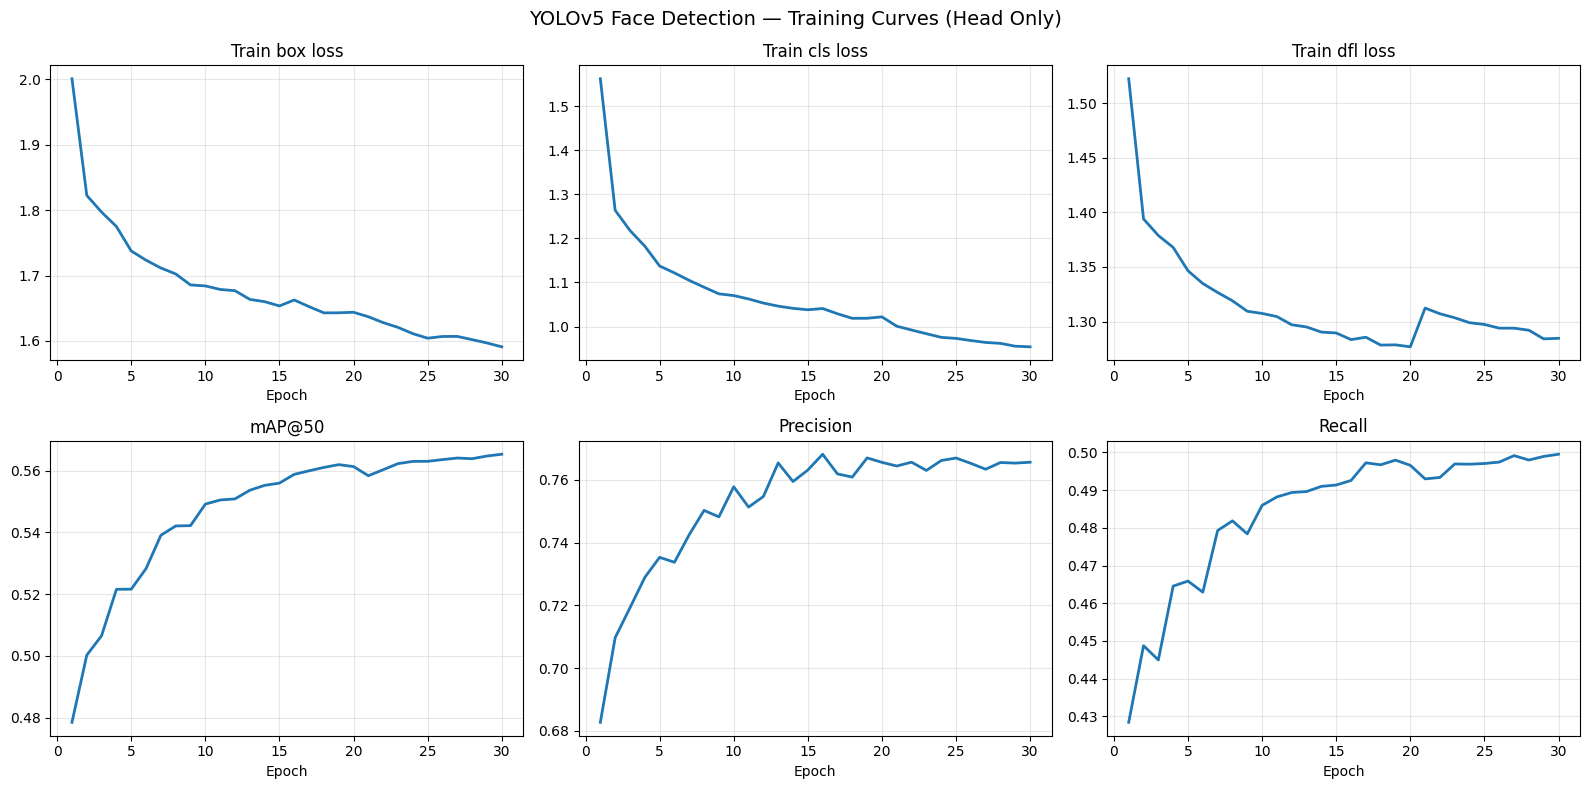

Training curves saved.


In [13]:
results_csv = Path(results.save_dir) / "results.csv"
if results_csv.exists():
    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()   # Remove whitespace from headers

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("YOLOv5 Face Detection — Training Curves (Head Only)", fontsize=14)

    metrics_to_plot = [
        ("train/box_loss",  "Train box loss",  axes[0, 0]),
        ("train/cls_loss",  "Train cls loss",  axes[0, 1]),
        ("train/dfl_loss",  "Train dfl loss",  axes[0, 2]),
        ("metrics/mAP50(B)","mAP@50",          axes[1, 0]),
        ("metrics/precision(B)", "Precision",  axes[1, 1]),
        ("metrics/recall(B)",    "Recall",     axes[1, 2]),
    ]

    for col_name, title, ax in metrics_to_plot:
        if col_name in df.columns:
            ax.plot(df["epoch"], df[col_name], linewidth=2)
            ax.set_title(title)
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f"{title} (not found)")

    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Training curves saved.")
else:
    print("results.csv not found — skipping training curves plot.")

# 🖼️ **Inference on Validation Images**

We perform visual testing:

🔍 Detect faces in validation images  
🟩 Draw bounding boxes  
📊 Show confidence scores  

---

💡 This helps:
- Visually verify model predictions  
- Check detection quality  
- Identify false positives  

---

🎯 Only **face detections** are shown.

🚀 Running visual inference on Male Selfie Dataset...


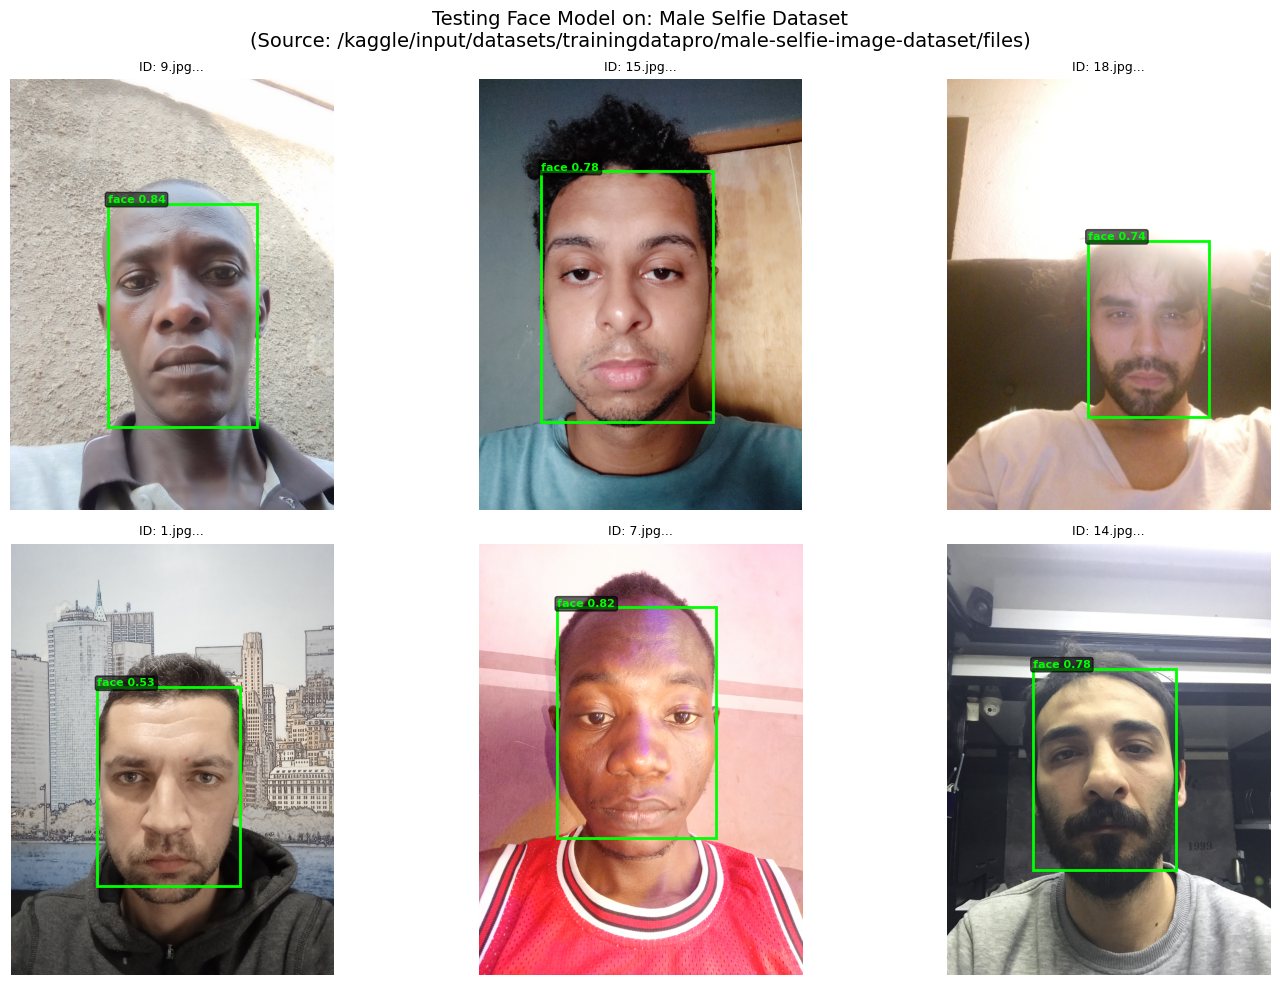

In [33]:
# ---- Path to the new Male Selfie Dataset ----
MALE_FACES_DIR = "/kaggle/input/datasets/trainingdatapro/male-selfie-image-dataset/files"

def visualize_detections(model, image_dir, num_images=6, conf_threshold=0.25):
    """
    Run inference on a sample of images from the new male face dataset.
    """
    # Look for common image extensions
    image_paths = list(Path(image_dir).glob("*.jpg")) + \
                  list(Path(image_dir).glob("*.jpeg")) + \
                  list(Path(image_dir).glob("*.png"))

    if len(image_paths) == 0:
        print(f"❌ No images found in: {image_dir}")
        print("Tip: Double check if the dataset is correctly attached to the notebook.")
        return

    # Pick a random subset (Fresh randomness every time)
    import random
    sample_paths = random.sample(image_paths, min(num_images, len(image_paths)))

    cols = 3
    rows = (len(sample_paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    
    # Flatten axes for easy iteration
    if rows == 1 and cols == 1: axes = [axes]
    else: axes = axes.flatten()

    for idx, img_path in enumerate(sample_paths):
        ax = axes[idx]

        # Run inference using the best fine-tuned model
        preds = model.predict(
            source    = str(img_path),
            conf      = conf_threshold,
            iou       = 0.45,
            imgsz     = IMG_SIZE,
            device    = 0,
            verbose   = False,
        )

        # Load and display image
        img = np.array(Image.open(img_path).convert("RGB"))
        ax.imshow(img)
        ax.set_title(f"ID: {img_path.name[:15]}...", fontsize=9)
        ax.axis("off")

        # Draw bounding boxes for detected faces
        result = preds[0]
        if result.boxes is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            
            for box, conf in zip(boxes, confs):
                x1, y1, x2, y2 = box
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor="lime", facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(
                    x1, y1 - 5, f"face {conf:.2f}",
                    color="lime", fontsize=8, weight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.6)
                )

    # Clean up empty subplots
    for idx in range(len(sample_paths), len(axes)):
        axes[idx].axis("off")

    plt.suptitle(f"Testing Face Model on: Male Selfie Dataset\n(Source: {image_dir})", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run the test on the new Male Selfie images
print("🚀 Running visual inference on Male Selfie Dataset...")
visualize_detections(best_model, MALE_FACES_DIR, num_images=6, conf_threshold=0.25)

# 🧪 **Custom Image Testing**

Test the model on your own images:

📂 Supports:
- Single image  
- Folder of images  

---

🎯 Expected behavior:
- Human face → ✅ detected  
- Non-face (dog, cat, etc.) → ❌ ignored  

---

💡 Helps validate real-world performance.

Testing on 5 random images from 1000 total files...


/tmp/ipykernel_55/665947744.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


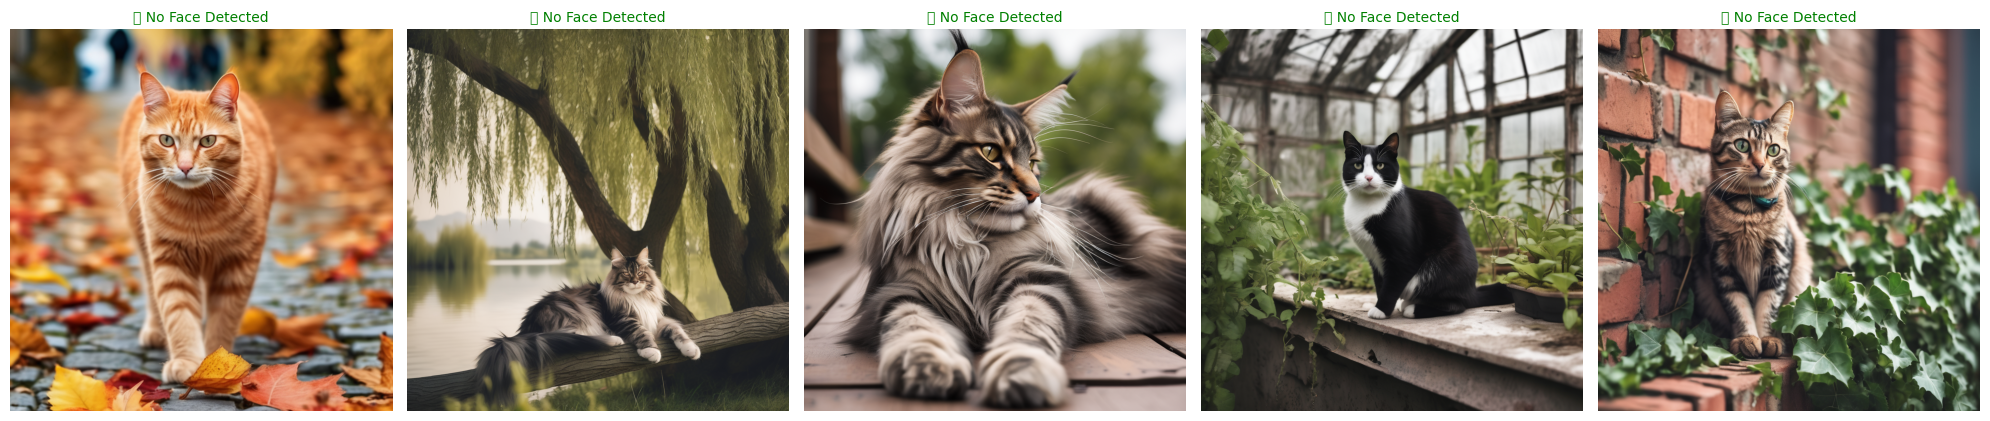

In [34]:
def test_five_random_images(model, image_dir, conf_threshold=0.25):
    # 1. Gather all image paths
    image_paths = list(Path(image_dir).glob("*.jpg")) + \
                  list(Path(image_dir).glob("*.jpeg")) + \
                  list(Path(image_dir).glob("*.png"))

    if len(image_paths) < 5:
        print(f"Not enough images in {image_dir}")
        return

    # 2. Pick exactly 5 random images
    sample_paths = random.sample(image_paths, 5)

    # 3. Setup the plot (1 row, 5 columns)
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    
    print(f"Testing on 5 random images from {len(image_paths)} total files...")

    for i, img_path in enumerate(sample_paths):
        # Run inference
        results = model.predict(source=str(img_path), conf=conf_threshold, device=0, verbose=False)
        
        img = Image.open(img_path).convert("RGB")
        axes[i].imshow(img)
        axes[i].axis("off")
        
        # Check if anything was (wrongly) detected as a face
        n_detected = len(results[0].boxes)
        if n_detected > 0:
            axes[i].set_title(f"⚠️ Detected {n_detected} Face(s)", color="orange", fontsize=10)
            # Draw the boxes
            for box in results[0].boxes.xyxy.cpu().numpy():
                x1, y1, x2, y2 = box
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="red", facecolor="none")
                axes[i].add_patch(rect)
        else:
            axes[i].set_title("✅ No Face Detected", color="green", fontsize=10)

    plt.tight_layout()
    plt.show()

# Run the test
test_five_random_images(best_model, CUSTOM_IMAGES_DIR)

# 📦 **Final Model Summary**

🎯 **Model Type:** YOLOv5 (Ultralytics)  
🧠 **Training Strategy:** Head Fine-Tuning Only  
👤 **Classes:** 1 (Face)  

---

📊 **Training Details:**
- Backbone ❄️ Frozen  
- Neck ❄️ Frozen  
- Head 🎯 Trained  

---

🏆 **Outputs:**
- Best model weights  
- Training plots  
- Detection results  

---

💡 **Usage:**
```python
from ultralytics import YOLO
model = YOLO("best_face_detector.pt")
results = model.predict("image.jpg")

In [36]:
# Values from the training output (already validated automatically)
MAP50    = 0.565
MAP5095  = 0.288
PRECISION = 0.766
RECALL   = 0.499

print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Pretrained model  : yolov5su.pt (small, ultralytics)")
print(f"Classes trained   : 1 (face only)")
print(f"Layers trained    : Detection head only (layer index 24)")
print(f"Layers frozen     : Backbone (0-9) + Neck (10-23)")
print(f"Epochs            : 30")
print(f"Best weights      : {BEST_MODEL_PATH}")
print(f"mAP@50            : {MAP50:.4f}")
print(f"mAP@50-95         : {MAP5095:.4f}")
print(f"Precision         : {PRECISION:.4f}")
print(f"Recall            : {RECALL:.4f}")
print("=" * 60)
print("\nTo load and use this model elsewhere:")
print("  from ultralytics import YOLO")
print(f"  model = YOLO('{BEST_MODEL_PATH}')")
print("  results = model.predict('your_image.jpg', conf=0.25)")
print("\nNote: This model only outputs class 0 = 'face'.")
print("All other objects (dogs, cats, cars...) produce no detections.")

# Copy best weights to working root for easy access
shutil.copy(BEST_MODEL_PATH, "/kaggle/working/best_face_detector.pt")
print("\nBest model copied to: /kaggle/working/best_face_detector.pt")


TRAINING SUMMARY
Pretrained model  : yolov5su.pt (small, ultralytics)
Classes trained   : 1 (face only)
Layers trained    : Detection head only (layer index 24)
Layers frozen     : Backbone (0-9) + Neck (10-23)
Epochs            : 30
Best weights      : /kaggle/working/face_detection/face_head_only/weights/best.pt
mAP@50            : 0.5650
mAP@50-95         : 0.2880
Precision         : 0.7660
Recall            : 0.4990

To load and use this model elsewhere:
  from ultralytics import YOLO
  model = YOLO('/kaggle/working/face_detection/face_head_only/weights/best.pt')
  results = model.predict('your_image.jpg', conf=0.25)

Note: This model only outputs class 0 = 'face'.
All other objects (dogs, cats, cars...) produce no detections.

Best model copied to: /kaggle/working/best_face_detector.pt
